# Hybrid Chunk Sampler — Tests & Comparisons

Exercises `dreamerv4uwm.inference.HybridChunkSampler` (hybrid KV-cached chunk denoising:
causal-into-cache + bidirectional-within-chunk; first `k` of `m` frames committed per chunk)
and benchmarks it against:

1. The existing `AutoRegressiveForwardDynamics` (frame-by-frame KV-cached AR).
2. Batched-AR — same AR sampler driven with a batch of independent rollouts in parallel,
   for a throughput-vs-quality comparison along a different axis (parallel-rollout cost vs
   per-rollout extra denoising compute).

**Prereq**: the checkpoint must have been trained with `cfg.denoiser.horizon_aware=True`.
The hybrid sampler prints a loud warning if not — predictions go OOD without it.

Structured as five sections:
- §1 Setup (imports, config, checkpoint, seed frames).
- §2 Existing AR baseline.
- §3 Hybrid sampler — three configurations (`m=1,k=1`, `m=4,k=4` chunk-wise, `m=4,k=1` MPC-style).
- §4 Batched-AR — same AR sampler with B > 1.
- §5 Comparison — videos side-by-side and per-frame wall-clock timing.

## §1 Setup

In [1]:
%load_ext autoreload
%autoreload 2

import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import mediapy
from torch.nn.functional import interpolate

from dreamerv4uwm.models.utils import load_tokenizer, load_denoiser
from dreamerv4uwm.datasets import G1ChunkDataset
from dreamerv4uwm.sampling import AutoRegressiveForwardDynamics
from dreamerv4uwm.inference import HybridChunkSampler

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
resolution = (256, 256)
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [2]:
# Config (Hydra-compose to match the same composition the trainer uses).
from hydra import initialize, compose
from omegaconf import OmegaConf

with initialize(version_base=None, config_path='scripts/config'):
    cfg = compose(config_name='dynamics/g1-large.yaml')

# ===> EDIT THESE TWO PATHS to your checkpoints <===
dynamics_ckpt  = '/scratch/rk4342/projects/dreamerV4-UWM/checkpoints/dynamics/g1-may19-unified-scratch-v2/115000.pt'
tokenizer_ckpt = '/scratch/rk4342/projects/dreamerV4-UWM/checkpoints/tokenizer/g1.pt'

cfg.dynamics_ckpt = dynamics_ckpt
cfg.tokenizer_ckpt = tokenizer_ckpt

# Heads-up if the loaded checkpoint wasn't trained with horizon-aware attention.
if not getattr(cfg.denoiser, 'horizon_aware', False):
    print('⚠️  cfg.denoiser.horizon_aware is False/missing — the hybrid sampler')
    print('   assumes bidir-within-horizon training and will warn at construction.')
    print('   To override (override cfg, not the checkpoint), uncomment below:')
    print('# cfg.denoiser.horizon_aware = True')

denoiser  = load_denoiser(cfg, device, max_num_forward_steps=512)
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=512)
denoiser = denoiser.eval().to(device)
tokenizer = tokenizer.eval().to(device)

print(f'Denoiser params: {sum(p.numel() for p in denoiser.parameters()):,}')
print(f'horizon_aware:   {getattr(cfg.denoiser, "horizon_aware", False)}')
print(f'context_length:  {cfg.denoiser.context_length}')
print(f'num_noise_levels: {cfg.denoiser.num_noise_levels}')
print(f'n_actions:        {cfg.denoiser.n_actions}')

/ext3/miniconda/envs/dreamerv4/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/g1-large.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


Denoiser params: 689,582,614
horizon_aware:   True
context_length:  64
num_noise_levels: 128
n_actions:        22


In [11]:
# Pull a single episode for the seed/context.
# ===> EDIT this path to your dataset root <===
G1_DATA_PATH = '/scratch/rk4342/datasets/G1/wm'

dataset = G1ChunkDataset(
    data_dir=G1_DATA_PATH,
    window_size=128,
    stride=128,
    split='train',
    train_fraction=0.9,
    split_seed=123,
)

batch = dataset[torch.randint(len(dataset), (1,)).item()]
imgs    = batch['image']                        # (T, C, H, W)
actions = batch['action'][:, :cfg.denoiser.n_actions]   # (T, n_act)
imgs    = interpolate(imgs, resolution).to(device=device)[None]   # (1, T, C, H, W)
actions = actions.to(device=device)[None]                          # (1, T, n_act)

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    latents      = tokenizer.encode(imgs)
    imgs_recon   = tokenizer.decode(latents)

print(f'imgs    : {tuple(imgs.shape)}')
print(f'actions : {tuple(actions.shape)}')
print(f'latents : {tuple(latents.shape)}')

def plot_video(video, fps=10, title=None):
    """video: (T, C, H, W) in [0, 1]."""
    frames = video.cpu().permute(0, 2, 3, 1).to(torch.float32).numpy()
    frames = (frames.clip(0.0, 1.0) * 255).astype('uint8')
    if title:
        print(title)
    mediapy.show_video(frames, fps=fps)

plot_video(imgs[0], title='Ground truth')

G1[train]: 4117 windows from 276 episodes (of 307 total) across 228 chunks
imgs    : (1, 128, 3, 256, 256)
actions : (1, 128, 22)
latents : (1, 128, 256, 32)
Ground truth


This browser does not support the video tag.


In [12]:
# Common rollout parameters.
T_ctx              = 4                          # number of seed frames committed before rollout
num_pred_steps     = 64                         # frames to predict
denoising_steps    = 8                          # K — per-chunk Euler steps for both samplers
context_cond_tau   = 0.99                       # noise level for committed-context K/V (legacy AR)
max_forward_steps  = 128                        # KV-cache buffer size (must be >= T_ctx + max chunk + 1)

imgs_ctx    = imgs[:, :T_ctx]                   # (1, T_ctx, C, H, W)
actions_ctx = actions[:, :T_ctx]                # (1, T_ctx, n_act)
latents_ctx = latents[:, :T_ctx]                # (1, T_ctx, N_lat, D_lat)
future_actions = actions[:, T_ctx:T_ctx + num_pred_steps]   # (1, num_pred_steps, n_act)

print(f'T_ctx={T_ctx}, num_pred_steps={num_pred_steps}, K={denoising_steps}')

T_ctx=4, num_pred_steps=64, K=8


## §2 Baseline — Autoregressive Forward Dynamics (existing)

The reference implementation: one frame per `step()`, fully causal KV cache, joint policy denoising.

In [13]:
ar_pol = AutoRegressiveForwardDynamics(
    denoiser=denoiser,
    tokenizer=tokenizer,
    mode='policy',
    context_length=max_forward_steps,
    max_forward_steps=max_forward_steps,
    context_cond_tau=context_cond_tau,
    denoising_step_count=denoising_steps,
    device=device,
    dtype=torch.float32,
)

frames_ar, acts_ar = [], []
t0 = time.perf_counter()
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    ar_pol.reset(imgs_ctx, actions_ctx)
    for t in range(num_pred_steps):
        img_t, act_t = ar_pol.step()
        frames_ar.append(img_t.detach().cpu())
        acts_ar.append(act_t.detach().cpu())
torch.cuda.synchronize()
ar_time = time.perf_counter() - t0

video_ar = torch.stack(frames_ar, dim=1)[0]
acts_ar_seq = torch.stack(acts_ar, dim=1)[0]

print(f'AR (policy, m=1)        — {num_pred_steps} frames in {ar_time:.2f}s '
      f'(per-frame {ar_time / num_pred_steps * 1000:.1f} ms)')
plot_video(video_ar.to(torch.float32), title=f'AR baseline, K={denoising_steps}')

AR (policy, m=1)        — 64 frames in 9.94s (per-frame 155.3 ms)
AR baseline, K=8


This browser does not support the video tag.


## §3 Hybrid Chunk Sampler

Run three configurations against the same seed context:
1. `m=1, k=1` — closest analog of AR (should be roughly equivalent within numerical noise).
2. `m=4, k=4` — chunk-wise: 4 frames denoised together, all committed per chunk.
3. `m=4, k=1` — MPC-style: 4-frame lookahead, only the first committed.

The sampler returns *latents*; we decode them with the tokenizer to compare against the AR
frames. Note the tokenizer here is called without its KV cache — it re-decodes from scratch
each frame. (The AR baseline shares the tokenizer cache with the denoiser cache as a single
object; for a fair throughput comparison see §5 where we strip the tokenizer entirely.)

In [14]:
def run_hybrid(chunk_size, commit_per_chunk, n_frames=num_pred_steps,
               clean_commit_pass=True, commit_noise_n=0.0):
    """Run HybridChunkSampler. Returns (latents, actions, wall_time)."""
    sampler = HybridChunkSampler(
        denoiser=denoiser,
        cfg=cfg,
        chunk_size=chunk_size,
        commit_per_chunk=commit_per_chunk,
        num_diffusion_steps=denoising_steps,
        action_noise_std=1.0,
        commit_noise_n=commit_noise_n,
        clean_commit_pass=clean_commit_pass,
        device=device,
        dtype=torch.bfloat16,
    )
    sampler.init_cache(batch_size=latents_ctx.shape[0])
    sampler.warm_up_cache(latents_ctx, actions_ctx)

    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        z_gen, a_gen = sampler.generate(n_frames=n_frames)
    torch.cuda.synchronize()
    return z_gen, a_gen, time.perf_counter() - t0


def decode_latents(z):
    """(B, T, N_lat, D_lat) → (B, T, C, H, W) via tokenizer.decode (no cache)."""
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        return tokenizer.decode(z.to(device=device, dtype=torch.bfloat16))

In [25]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
      # z_h11, a_h11, t_h11 = run_hybrid(chunk_size=1, commit_per_chunk=1)
      z_h44, a_h44, t_h44 = run_hybrid(chunk_size=8, commit_per_chunk=8)
      # z_h41, a_h41, t_h41 = run_hybrid(chunk_size=4, commit_per_chunk=1)

print(f'Hybrid m=1,k=1 (AR-like) — {num_pred_steps} frames in {t_h11:.2f}s '
      f'({t_h11/num_pred_steps*1000:.1f} ms/frame)')
print(f'Hybrid m=4,k=4 (chunkwise) — {num_pred_steps} frames in {t_h44:.2f}s '
      f'({t_h44/num_pred_steps*1000:.1f} ms/frame)')
print(f'Hybrid m=4,k=1 (MPC-style) — {num_pred_steps} frames in {t_h41:.2f}s '
      f'({t_h41/num_pred_steps*1000:.1f} ms/frame)')

Hybrid m=1,k=1 (AR-like) — 64 frames in 8.38s (130.9 ms/frame)
Hybrid m=4,k=4 (chunkwise) — 64 frames in 2.36s (36.9 ms/frame)
Hybrid m=4,k=1 (MPC-style) — 64 frames in 15.51s (242.4 ms/frame)


In [26]:
video_h11 = decode_latents(z_h11)[0]
video_h44 = decode_latents(z_h44)[0]
video_h41 = decode_latents(z_h41)[0]

plot_video(video_h11.to(torch.float32), title='Hybrid m=1, k=1 (AR-equivalent)')
plot_video(video_h44.to(torch.float32), title='Hybrid m=4, k=4 (chunkwise)')
plot_video(video_h41.to(torch.float32), title='Hybrid m=4, k=1 (MPC-style)')

Hybrid m=1, k=1 (AR-equivalent)


This browser does not support the video tag.


Hybrid m=4, k=4 (chunkwise)


This browser does not support the video tag.


Hybrid m=4, k=1 (MPC-style)


This browser does not support the video tag.


## §4 Batched Autoregressive

Same `AutoRegressiveForwardDynamics`, but with `B > 1` independent rollouts in one forward.
Tests whether throughput per rollout scales sub-linearly with batch (GPU under-utilization
at B=1?) — and provides a different lever to compare against multi-frame chunking.

In [18]:
def run_batched_ar(B, n_frames=num_pred_steps):
    """Run AR with batch size B. Returns (frames (B,T,C,H,W), wall_time)."""
    imgs_ctx_b    = imgs_ctx.expand(B, -1, -1, -1, -1).contiguous()
    actions_ctx_b = actions_ctx.expand(B, -1, -1).contiguous()
    ar = AutoRegressiveForwardDynamics(
        denoiser=denoiser,
        tokenizer=tokenizer,
        mode='policy',
        context_length=max_forward_steps,
        max_forward_steps=max_forward_steps,
        context_cond_tau=context_cond_tau,
        denoising_step_count=denoising_steps,
        device=device,
        dtype=torch.float32,
    )
    frames_b = []
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        ar.reset(imgs_ctx_b, actions_ctx_b)
        for t in range(n_frames):
            img_t, _ = ar.step()
            frames_b.append(img_t.detach().cpu())
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    video = torch.stack(frames_b, dim=1)   # (B, T, C, H, W)
    return video, elapsed

B_values = [1, 2, 4, 8]
batched_results = {}
for B in B_values:
    try:
        video_b, t_b = run_batched_ar(B)
        batched_results[B] = (video_b, t_b)
        print(f'AR B={B}: {num_pred_steps} frames × {B} rollouts in {t_b:.2f}s '
              f'({t_b/num_pred_steps*1000:.1f} ms/frame, '
              f'{t_b/(num_pred_steps*B)*1000:.1f} ms/(frame·rollout))')
    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            print(f'AR B={B}: OOM — stopping the sweep')
            torch.cuda.empty_cache()
            break
        raise

KeyboardInterrupt: 

## §5 Comparison

Three views:
1. **Per-frame wall-clock** — hybrid configs vs AR (B=1) vs batched-AR (per-rollout cost).
2. **Hybrid scaling sweep** — `m ∈ {1, 2, 4, 8}` with `k=1` (MPC) and `k=m` (chunkwise).
3. **Side-by-side video grid** — visual fidelity check.

In [19]:
# Timing summary table.
rows = [
    ('AR (B=1)',              ar_time, num_pred_steps, 1),
    ('Hybrid m=1, k=1',       t_h11,   num_pred_steps, 1),
    ('Hybrid m=4, k=4',       t_h44,   num_pred_steps, 1),
    ('Hybrid m=4, k=1',       t_h41,   num_pred_steps, 1),
]
for B, (_, t_b) in batched_results.items():
    rows.append((f'AR (B={B})', t_b, num_pred_steps, B))

print(f'{"method":<22} {"wall(s)":>9} {"ms/frame":>10} {"ms/(frame·rollout)":>22}')
for name, t, n, b in rows:
    print(f'{name:<22} {t:>9.2f} {t/n*1000:>10.1f} {t/(n*b)*1000:>22.1f}')

method                   wall(s)   ms/frame     ms/(frame·rollout)
AR (B=1)                    9.94      155.3                  155.3
Hybrid m=1, k=1             8.38      130.9                  130.9
Hybrid m=4, k=4             4.12       64.4                   64.4
Hybrid m=4, k=1            15.51      242.4                  242.4


Hybrid m= 1, k= 1 (MPC      ): 8.54s (133.5 ms/frame)
Hybrid m= 1, k= 1 (chunkwise): 8.42s (131.6 ms/frame)
Hybrid m= 2, k= 1 (MPC      ): 14.67s (229.1 ms/frame)
Hybrid m= 2, k= 2 (chunkwise): 5.59s (87.4 ms/frame)
Hybrid m= 4, k= 1 (MPC      ): 13.45s (210.1 ms/frame)
Hybrid m= 4, k= 4 (chunkwise): 3.34s (52.2 ms/frame)
Hybrid m= 8, k= 1 (MPC      ): 19.59s (306.1 ms/frame)
Hybrid m= 8, k= 8 (chunkwise): 2.37s (37.0 ms/frame)


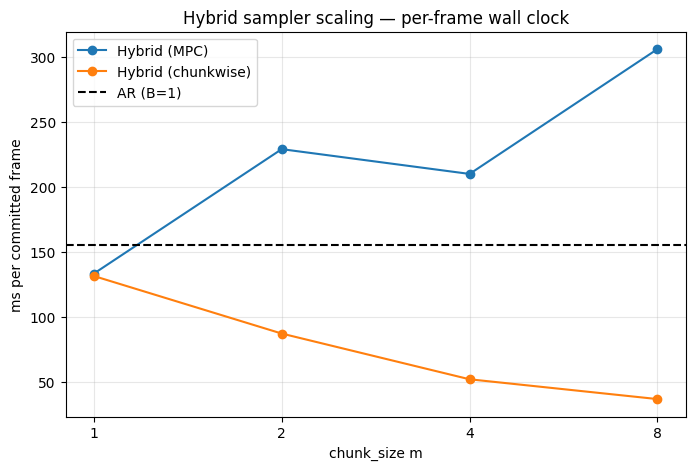

In [21]:
# Hybrid scaling sweep: m ∈ {1, 2, 4, 8}, both MPC (k=1) and chunkwise (k=m).
m_values = [1, 2, 4, 8]
sweep_results = {}
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    for m in m_values:
        for kind, k in (('MPC', 1), ('chunkwise', m)):
            if k > m:
                continue
            try:
                _, _, t = run_hybrid(chunk_size=m, commit_per_chunk=k)
                sweep_results[(m, kind)] = t
                print(f'Hybrid m={m:>2}, k={k:>2} ({kind:<9}): {t:.2f}s '
                    f'({t/num_pred_steps*1000:.1f} ms/frame)')
            except RuntimeError as e:
                if 'out of memory' in str(e).lower():
                    print(f'Hybrid m={m}, k={k}: OOM')
                    torch.cuda.empty_cache()
                    continue
                raise

fig, ax = plt.subplots(figsize=(8, 5))
for kind in ('MPC', 'chunkwise'):
    xs = [m for (m, k) in sweep_results if k == kind]
    ys = [sweep_results[(m, kind)] / num_pred_steps * 1000 for m in xs]
    ax.plot(xs, ys, marker='o', label=f'Hybrid ({kind})')
ax.axhline(ar_time / num_pred_steps * 1000, color='k', linestyle='--', label='AR (B=1)')
ax.set_xlabel('chunk_size m')
ax.set_ylabel('ms per committed frame')
ax.set_xscale('log', base=2)
ax.set_xticks(m_values); ax.set_xticklabels([str(m) for m in m_values])
ax.legend()
ax.set_title('Hybrid sampler scaling — per-frame wall clock')
ax.grid(True, alpha=0.3)
plt.show()

In [22]:
# Side-by-side videos — visual fidelity comparison.
# Decoder is non-deterministic across runs because of dropout-off bf16 numerics;
# differences below should reflect sampler behavior, not decoder noise.
def side_by_side(*videos, labels):
    """Stack (T, C, H, W) videos horizontally for a single playable comparison."""
    assert all(v.shape == videos[0].shape for v in videos)
    T = videos[0].shape[0]
    grid = torch.cat([v.cpu().to(torch.float32) for v in videos], dim=-1)   # along W
    print(' | '.join(labels))
    plot_video(grid)

side_by_side(
    video_ar.to(torch.float32),
    video_h11.to(torch.float32),
    video_h44.to(torch.float32),
    video_h41.to(torch.float32),
    labels=['AR', 'Hybrid m=1,k=1', 'Hybrid m=4,k=4', 'Hybrid m=4,k=1'],
)

AR | Hybrid m=1,k=1 | Hybrid m=4,k=4 | Hybrid m=4,k=1


This browser does not support the video tag.


## Notes & next things to try

- **`commit_noise_n`** — small value (e.g. `0.05`) perturbs committed K/V the way you do for
  AR long-horizon stability. Toggle on if you see hybrid rollouts drift after many chunks.
- **`clean_commit_pass=False`** — skip the extra pass that recomputes K/V from the clean chunk.
  Saves one forward per chunk; quality cost depends on K (large K → small).
- **Quality metric** — for a quantitative comparison beyond eyeballing, compute MSE of
  predicted vs ground-truth `imgs[:, T_ctx:T_ctx + num_pred_steps]` (or LPIPS) over the rollout.
  Hybrid `m>1` is expected to do as well or better than AR on smoothly-evolving scenes; on
  multimodal scenes the bidir lookahead can help avoid mode-collapse.
- **Cache-overflow behavior** — the hybrid sampler keeps cache size ≤ `context_length - m`.
  For very long rollouts the oldest cached frames get dropped (rolling buffer in `KVCache`).
  This mirrors the windowed-attention behavior the model was trained with.